# CMU Delphi Epidata - Lane B (backup: the agent's output, captured)

**SISMID 2026 - Day 2, 11:00.** You cannot get Facebook *posts*, but you can get the
thing that actually mattered epidemiologically: the **COVID-19 Trends and Impact Survey**
(CTIS), which Facebook ran with **CMU Delphi**, millions of responses, free through the
**Epidata API** with no key.

> Captured example of what a coding agent (Codex, Claude Code, or Antigravity CLI)
> produces from the **Lane A** prompts.

**Where to look it up (Delphi calls this "the Facebook Covid Survey"):**

- CTIS Dashboard: <https://delphi.cmu.edu/covidcast/survey-results/>
- About CTIS: <https://delphi.cmu.edu/epidemic-signals/ctis/>
- Signal dictionary (defines `smoothed_wcli`): <https://cmu-delphi.github.io/delphi-epidata/api/covidcast-signals/fb-survey.html>
- Browse all Delphi indicators: <https://delphi.cmu.edu/epiportal/>


## About this data source

**CMU Delphi's COVID-19 Trends and Impact Survey (CTIS)**, which Delphi itself labels
*"the Facebook Covid Survey"*. For two years Facebook asked millions of users whether they
or anyone in their household was ill, and Carnegie Mellon turned the answers into a public
health signal. Think of it as: *"a nationwide symptom survey, every day, free."*

- **Explore it in a browser (CTIS Dashboard):**
  <https://delphi.cmu.edu/covidcast/survey-results/>
- About CTIS: <https://delphi.cmu.edu/epidemic-signals/ctis/>
- Signal dictionary (defines the `smoothed_wcli` we pull):
  <https://cmu-delphi.github.io/delphi-epidata/api/covidcast-signals/fb-survey.html>
- Browse all Delphi indicators: <https://delphi.cmu.edu/epiportal/>

> Unusually for a novel stream, it ships **error bars and sample sizes**. It ran 2020 to
> **June 2022**, so it is a benchmark, not a live feed.


## Step 0: helpers, and your query


In [1]:
import pandas as pd, matplotlib.pyplot as plt, os, json, re, time
import urllib.request, urllib.parse

UA = {'User-Agent': 'SISMID2026-course/1.0 (your-email@example.com)'}

def cache_path(fname):
    for p in (f'../data/{fname}', f'data/{fname}', f'./{fname}'):
        if os.path.exists(p): return p
    return None

def get_json(url, timeout=45):
    return json.loads(urllib.request.urlopen(
        urllib.request.Request(url, headers=UA), timeout=timeout).read())

EPIDATA = 'https://api.delphi.cmu.edu/epidata/covidcast/'

# ===== EDIT for your own signal / place =====
SOURCE, SIGNAL = 'fb-survey', 'smoothed_wcli'   # % COVID-like illness, weighted
GEO_TYPE, GEO  = 'state', 'ga'
WINDOWS = ['20200901-20201231','20210101-20210630',
           '20210701-20211231','20220101-20220625']
# ============================================

def epidata(**params):
    d = get_json(EPIDATA + '?' + urllib.parse.urlencode(params), timeout=60)
    return d.get('epidata') or []


## Step 1: pull the Facebook symptom survey

**Prompt used (Lane A):**

> *Using the CMU Delphi Epidata COVIDcast API (https://api.delphi.cmu.edu/epidata/*
> *covidcast/, free, no key), pull data_source='fb-survey', signal='smoothed_wcli',*
> *geo_type='state', geo_value='ga', daily, from Sept 2020 through June 2022 (query in*
> *chunks). Return a tidy DataFrame with date, value, stderr, sample_size, and report the*
> *date range and mean sample size.*


In [2]:
# --- Produced by the agent from the Plan A / Step 1 prompt ---
rows = []
try:
    for w in WINDOWS:
        got = epidata(data_source=SOURCE, signal=SIGNAL, time_type='day',
                      geo_type=GEO_TYPE, geo_value=GEO, time_values=w)
        rows += [{'date': str(r['time_value']), 'value': r['value'],
                  'stderr': r.get('stderr'), 'sample_size': r.get('sample_size')} for r in got]
        time.sleep(0.8)
    if not rows: raise RuntimeError('no rows returned')
    fb = pd.DataFrame(rows)
except Exception as e:
    p = cache_path('delphi_fb_survey_ga.csv')
    print('Live Epidata pull failed:', e, '-> cache', p)
    fb = pd.read_csv(p)

fb['date'] = pd.to_datetime(fb['date'], format='%Y%m%d')
fb = fb.sort_values('date')
print(f"{len(fb)} days, {fb['date'].min().date()} -> {fb['date'].max().date()}")
print(f"mean sample size: {fb['sample_size'].mean():,.0f} respondents/day")
fb.head()


663 days, 2020-09-01 -> 2022-06-25
mean sample size: 5,011 respondents/day


,date,value,stderr,sample_size
0,2020-09-01,0.983199,0.156453,6838.9231
1,2020-09-02,1.008630,0.140087,8146.9057
2,2020-09-03,1.027148,0.141542,8060.9110
3,2020-09-04,0.941238,0.112359,7988.9178
4,2020-09-05,0.898933,0.110264,7759.9307


## Step 2: plot it, with its uncertainty

This is a **survey**, so every point has a standard error and a sample size. That is
unusual and valuable: most novel data streams give you no uncertainty at all.

**Prompt used (Lane A):**

> *Plot % COVID-like illness over time with a 95% confidence band from stderr.*


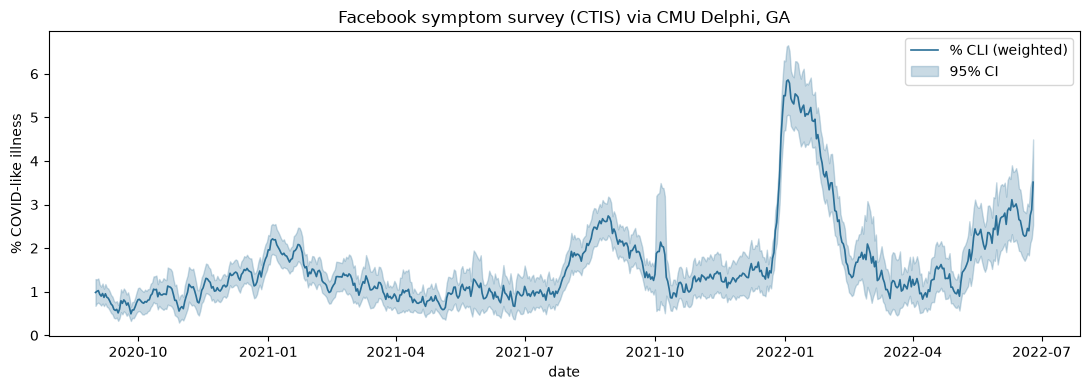

In [3]:
plt.figure(figsize=(11,4))
plt.plot(fb['date'], fb['value'], lw=1.2, color='#2A6F97', label='% CLI (weighted)')
if fb['stderr'].notna().any():
    plt.fill_between(fb['date'], fb['value']-1.96*fb['stderr'],
                     fb['value']+1.96*fb['stderr'], alpha=0.25, color='#2A6F97',
                     label='95% CI')
plt.ylabel('% COVID-like illness'); plt.xlabel('date')
plt.title(f'Facebook symptom survey (CTIS) via CMU Delphi, {GEO.upper()}')
plt.legend(); plt.tight_layout(); plt.show()


## Step 3: sanity-check, and notice when it stops

Look at the last date. The survey **ended in June 2022**, so this is a historical stream,
excellent for backtesting and teaching, useless for a live dashboard. Another reminder
that novel data streams come and go.

**Prompt used (Lane A):**

> *Report the date range, the %CLI range, missing values, and the peak date. Then tell me*
> *the last available date and what that implies about using this signal live.*


In [4]:
print('date range   :', fb['date'].min().date(), 'to', fb['date'].max().date())
print('%CLI range   :', round(fb['value'].min(),2), 'to', round(fb['value'].max(),2))
print('missing      :'); print(fb[['value','stderr','sample_size']].isna().sum())
print('peak week    :', fb.loc[fb['value'].idxmax(), 'date'].date(),
      '->', round(fb['value'].max(),2), '% CLI')
fb.to_csv('delphi_fb_survey.csv', index=False)
print('saved delphi_fb_survey.csv')


date range   : 2020-09-01 to 2022-06-25
%CLI range   : 0.49 to 5.86
missing      :
value          0
stderr         0
sample_size    0
dtype: int64
peak week    : 2022-01-03 -> 5.86 % CLI
saved delphi_fb_survey.csv


## Step 4: the rest of the Delphi catalogue

Epidata is a hub, not one stream. Other free sources worth knowing (availability varies,
so always check the returned date range):

| source | what it is |
|---|---|
| `fb-survey` | Facebook/CTIS symptom survey (2020-2022) |
| `doctor-visits` | outpatient visits with CLI, from claims |
| `chng` | Change Healthcare claims-based signals |
| `hhs` / `nhsn` | hospital admissions |
| `google-symptoms` | Google symptom search volumes |
| `nchs-mortality` | death certificate data |

The same `epidata()` helper queries any of them: change `data_source` and `signal`.

**Prompt used (Lane A):**

> *Delphi is a hub. Probe whether other sources have data for Georgia in early 2021,*
> *for example doctor-visits (smoothed_adj_cli), and tell me which are still current.*


In [5]:
# quick probe: does a source have data in a window you care about?
for src, sig in [('fb-survey','smoothed_wcli'), ('doctor-visits','smoothed_adj_cli')]:
    try:
        got = epidata(data_source=src, signal=sig, time_type='day',
                      geo_type='state', geo_value='ga', time_values='20210101-20210107')
        print(f'{src:16s} {sig:20s} -> {len(got)} rows in that week')
    except Exception as e:
        print(f'{src:16s} probe failed: {e}')
    time.sleep(0.8)


fb-survey        smoothed_wcli        -> 7 rows in that week
doctor-visits    smoothed_adj_cli     -> 7 rows in that week


## Reflection

- This is the honest answer to *"can we use Facebook data?"*: not posts, but a
  **massive, aggregated, privacy-preserving symptom survey**, free and documented.
- It ships **uncertainty** (stderr, sample size), which almost no other novel stream does.
- It **ended in June 2022**, so treat it as a historical benchmark, and let that fact
  teach the fragility point.

**Stretch:** swap `GEO` to your own state, or `SOURCE`/`SIGNAL` to `doctor-visits`, and
compare the two signals over the same period.
